In [ ]:
import os
import sys
import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgbm

from utils import user_utils

In [ ]:
raw_df = pd.read_csv('../data/creditcard.csv')
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
def get_outlier(df, columns=None, weight=1.5):
    """
    IQR 기반 이상치 탐지 함수
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    # 사용할 컬럼 선택
    if columns is None:
        columns = df.select_dtypes(include="number").columns
    
    # 사분위수 계산
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 기준
    lower_bound = Q1 - weight * IQR
    upper_bound = Q3 + weight * IQR
    
    # 이상치 마스크
    outlier_mask = pd.DataFrame(False, index=df.index, columns=columns)
    for col in columns:
        outlier_mask[col] = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
    
    # 결과 요약
    outlier_bounds = pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": outlier_mask.sum()
    })
    
    return outlier_bounds


In [ ]:
get_outlier(raw_df)

,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
Time,54201.500000,139320.500000,85119.000000,-73477.000000,266999.000000,0
V1,-0.920373,1.315642,2.236015,-4.274396,4.669664,7062
V2,-0.598550,0.803724,1.402274,-2.701961,2.907135,13526
V3,-0.890365,1.027196,1.917560,-3.766705,3.903536,3363
V4,-0.848640,0.743341,1.591981,-3.236612,3.131313,11148
V5,-0.691597,0.611926,1.303524,-2.646882,2.567212,12295
V6,-0.768296,0.398565,1.166861,-2.518586,2.148856,22965
V7,-0.554076,0.570436,1.124512,-2.240844,2.257204,8948
V8,-0.208630,0.327346,0.535976,-1.012593,1.131309,24134
V9,-0.643098,0.597139,1.240237,-2.503452,2.457494,8283


In [ ]:
amount_n = np.log1p(raw_df['Amount'])
raw_df.insert(0,'Amount Scaled', amount_n)
raw_df.drop(['Time','Amount'], axis=1, inplace=True)
raw_df

,Amount Scaled,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,5.014760,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,1.305626,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,5.939276,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,4.824306,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,4.262539,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,0.570980,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0
284803,3.249987,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0
284804,4.232366,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0
284805,2.397895,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0


In [ ]:
raw_df.to_csv('../data/scaledAmount_data.csv',index=False)

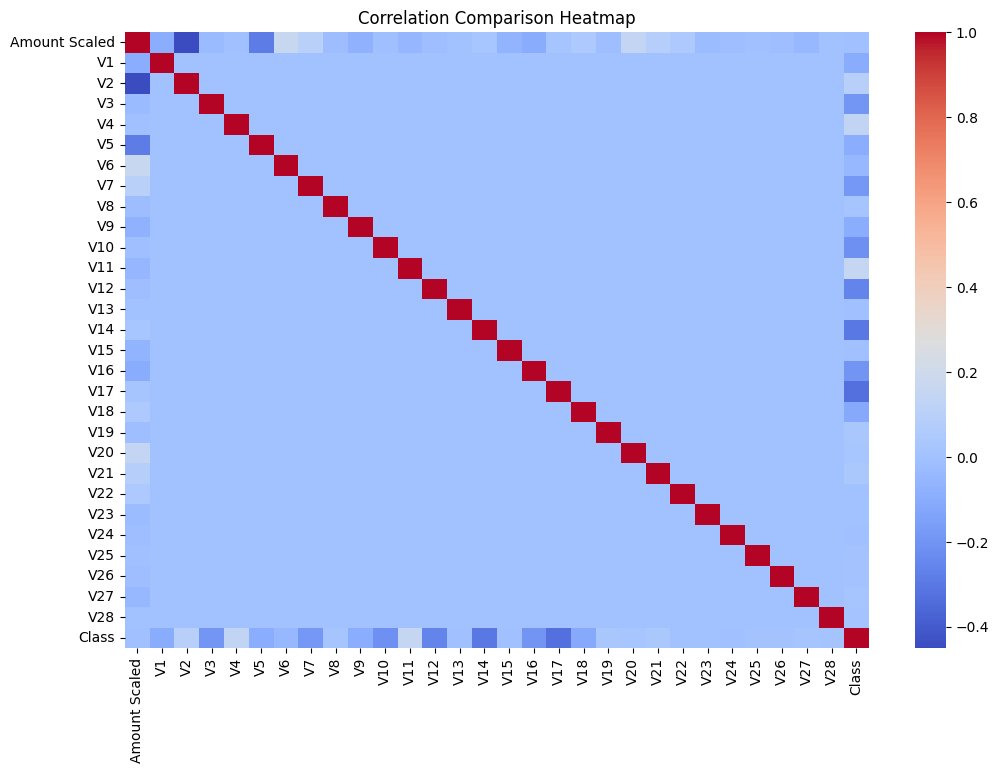

In [ ]:
columns = raw_df.select_dtypes(include="number").columns
corr_matrix = raw_df[columns].corr()
    
    # 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Comparison Heatmap")
plt.show()


In [9]:
def cap_outliers(df, columns=None, weight=1.5):
    """
    IQR 기반으로 이상치를 탐지하고 상한/하한 값으로 대체(Capping)하는 함수.
    
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    df_capped = df.copy()
    
    # 처리할 컬럼 선택
    if columns is None:
        columns = df_capped.select_dtypes(include=np.number).columns
    
    for col in columns:
        # 사분위수 및 IQR 계산
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 이상치 경계 계산
        lower_bound = Q1 - weight * IQR
        upper_bound = Q3 + weight * IQR
        
        # Capping 적용
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

In [10]:
scaled_df = pd.read_csv('../data/scaledAmount_data.csv')


In [14]:
X_feature = scaled_df.iloc[:,:-1]
y_label = scaled_df.iloc[:,-1]

capped_df = cap_outliers(X_feature)

KeyError: 'V14'